1\. **Maximum wind speed prediction at the Sprogø station**

The exercise goal is to predict the maximum wind speed occurring every 50 years even if no measure exists for such a period. The available data are only measured over 21 years at the Sprogø meteorological station located in Denmark. 

The annual maxima are supposed to fit a normal probability density function. However such function is not going to be estimated because it gives a probability from a wind speed maxima. Finding the maximum wind speed occurring every 50 years requires the opposite approach, the result needs to be found from a defined probability. That is the quantile function role and the exercise goal will be to find it. In the current model, it is supposed that the maximum wind speed occurring every 50 years is defined as the upper 2% quantile.

By definition, the quantile function is the inverse of the cumulative distribution function. The latter describes the probability distribution of an annual maxima. In the exercise, the cumulative probability $p_i$ for a given year i is defined as $p_i = i/(N+1)$ with $N = 21$, the number of measured years. Thus it will be possible to calculate the cumulative probability of every measured wind speed maxima. From those experimental points, the scipy.interpolate module will be very useful for fitting the quantile function. Finally the 50 years maxima is going to be evaluated from the cumulative probability of the 2% quantile.

Practically, load the dataset:

```python
import numpy as np
max_speeds = np.load('max-speeds.npy')
years_nb = max_speeds.shape[0]
```

Compute then the cumulative probability $p_i$ (`cprob`) and sort the maximum speeds from the data. Use then the  UnivariateSpline from scipy.interpolate to define a quantile function and thus estimate the probabilities.

In the current model, the maximum wind speed occurring every 50 years is defined as the upper 2% quantile. As a result, the cumulative probability value will be:

```python
fifty_prob = 1. - 0.02
```

So the storm wind speed occurring every 50 years can be guessed as:

``` python
fifty_wind = quantile_func(fifty_prob)
```



In [1]:
import numpy as np
max_speeds = np.load('max-speeds.npy')
years_nb = max_speeds.shape[0]

# Cumulative probability (cprob) and sorted data. 
cprob = np.arange(1,years_nb + 1) / (years_nb + 1)
speed_sorted = np.sort(max_speeds)
print(speed_sorted)

# Quantile function and probabilities estimation.
from scipy.interpolate import UnivariateSpline
quantile_func = UnivariateSpline(x = cprob,y = speed_sorted) # Because we will introduce prob. as input (we could aboid explicit " x " , " y ").
probabilities = quantile_func(speed_sorted)

fifty_prob = 1 - 0.02
fifty_wind = quantile_func(fifty_prob)
fifty_wind

[22.46 23.2  23.34 23.85 24.16 25.28 25.79 26.19 26.37 26.65 26.65 26.68
 26.73 26.75 26.76 27.93 28.09 28.79 29.75 30.19 32.97]


array(32.97989844)

2\. **Curve fitting of temperature in Alaska** 

The temperature extremes in Alaska for each month, starting in January, are given by (in degrees Celcius):

max:  17,  19,  21,  28,  33,  38, 37,  37,  31,  23,  19,  18

min: -62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58

* Plot these temperature extremes.
* Define a function that can describe min and max temperatures. 
* Fit this function to the data with scipy.optimize.curve_fit().
* Plot the result. Is the fit reasonable? If not, why?
* Is the time offset for min and max temperatures the same within the fit accuracy?


Answers to the questions:
1. Is the fit reasonable?
   - Tmax fit is reasonable (smooth sinusoidal behavior).
   - Tmin fit is less accurate due to stronger winter asymmetry.
2. Is the time offset (phase) the same for max and min temperatures?
   - Phase Tmax = 3.7234800492035887, Phase Tmin = 4.156036487961894
   - Phase difference ≈ -0.43 months, which is small compared to a 12-month period; thus the time offset for min and max temperatures is the same within fit accuracy.


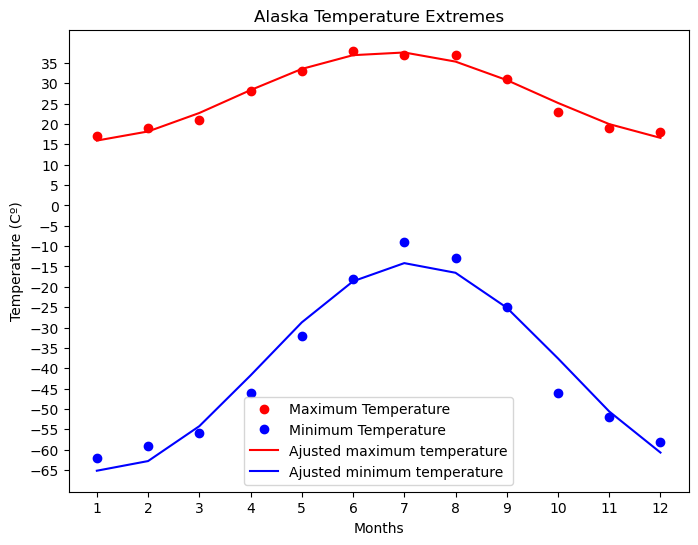

In [2]:
import numpy as np
Tmax = [17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18]
Tmin = [-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58]
months = np.arange(1,13)

# Extremes plotted.
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

plt.plot(months, Tmax, 'o',c='r',label='Maximum Temperature')
plt.plot(months, Tmin, 'o', c='b', label='Minimum Temperature') 

plt.xlabel('Months')
plt.ylabel('Temperature (Cº)')
plt.title('Alaska Temperature Extremes')

plt.xticks(np.arange(1, 13, 1))
plt.yticks(np.arange(-65, 40, 5))

# Function that can describe min and max temperatures.
def f(M, A, phase, D):
    return A * np.sin(2*np.pi/12 * (M-phase)) + D


# Fit this function to the data with scipy.optimize.curve_fit().
from scipy.optimize import curve_fit
params_max, _ = curve_fit(f, months, Tmax, p0=[10,1,0])
params_min, _ = curve_fit(f, months, Tmin, p0=[40,1,-60])

# Function plotted.
plt.plot(months,f(months, params_max[0], params_max[1], params_max[2]), c='r',label='Ajusted maximum temperature')
plt.plot(months, f(months, params_min[0], params_min[1], params_min[2]), c='b', label='Ajusted minimum temperature') 
plt.legend(loc='best')

# Answering the questions
print("\nAnswers to the questions:")
print("1. Is the fit reasonable?")
print("   - Tmax fit is reasonable (smooth sinusoidal behavior).")
print("   - Tmin fit is less accurate due to stronger winter asymmetry.")
print("2. Is the time offset (phase) the same for max and min temperatures?")
print(f"   - Phase Tmax = {params_max[1]}, Phase Tmin = {params_min[1]}")
print(f"   - Phase difference ≈ {params_max[1] - params_min[1]:.2f} months, which is small compared to a 12-month period; thus the time offset for min and max temperatures is the same within fit accuracy.")

3\. **2D minimization of a six-hump camelback function**

$$
f(x,y) = \left(4-2.1x^2+\frac{x^4}{3} \right) x^2 +xy + (4y^2 -4)y^2
$$

has multiple global and local minima. Find the global minima of this function.

Hints:

* Variables can be restricted to $-2 < x < 2$ and $-1 < y < 1$.
* Use numpy.meshgrid() and pylab.imshow() to find visually the regions.
* Use scipy.optimize.minimize(), optionally trying out several of its methods.

How many global minima are there, and what is the function value at those points? What happens for an initial guess of $(x, y) = (0, 0)$ ?


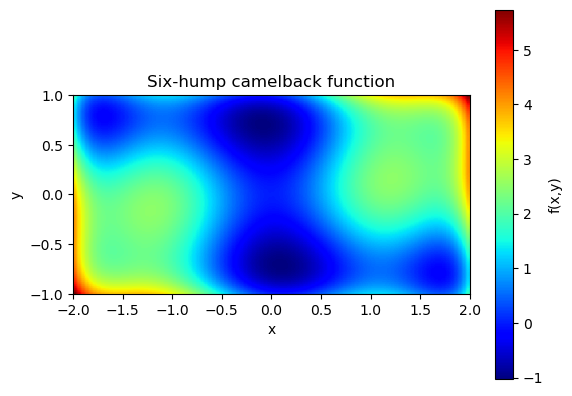

There are two global minima: [-0.08984221  0.71265607] [ 0.08984221 -0.71265608] 
 And a local minimum found from initial guess (0,0): [0. 0.]


In [3]:
import numpy as np
def f(x,y):
    return (4 - 2.1*x**2 + x**4/3)*x**2 + x*y + (4*y**2 - 4)*y**2
x = np.linspace(-2, 2, 100)
y = np.linspace(-1, 1, 100)

import matplotlib.pyplot as plt
import pylab
X, Y = np.meshgrid(x, y) # NumPy function that turns 1D coordinate vectors into a 2D grid of points so you can evaluate a function of two variables.
Z = f(X, Y)
# Lower origin places the (0,0) array index at the bottom-left so y increases upward like a mathematical plot.
pylab.imshow(Z, extent=[-2, 2, -1, 1], origin='lower', cmap='jet') 
plt.colorbar(label='f(x,y)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Six-hump camelback function')
plt.show()

from scipy.optimize import minimize
bounds = [(-2, 2), (-1, 1)]
res1 = minimize(lambda v: f(v[0], v[1]), x0=[0.5, 0.5], bounds=bounds)
res2 = minimize(lambda v: f(v[0], v[1]), x0=[-0.5, -0.5], bounds=bounds)
res3 = minimize(lambda v: f(v[0], v[1]), x0=[0, 0], bounds=bounds)
print('There are two global minima:',res1.x,res2.x,'\n','And a local minimum found from initial guess (0,0):',res3.x)

4\. **FFT of a simple dataset**

Performe a periodicity analysis on the lynxs-hares population

Dominant hare period: 10.5 years
Dominant lynx period: 10.5 years
As expected, periods are the same


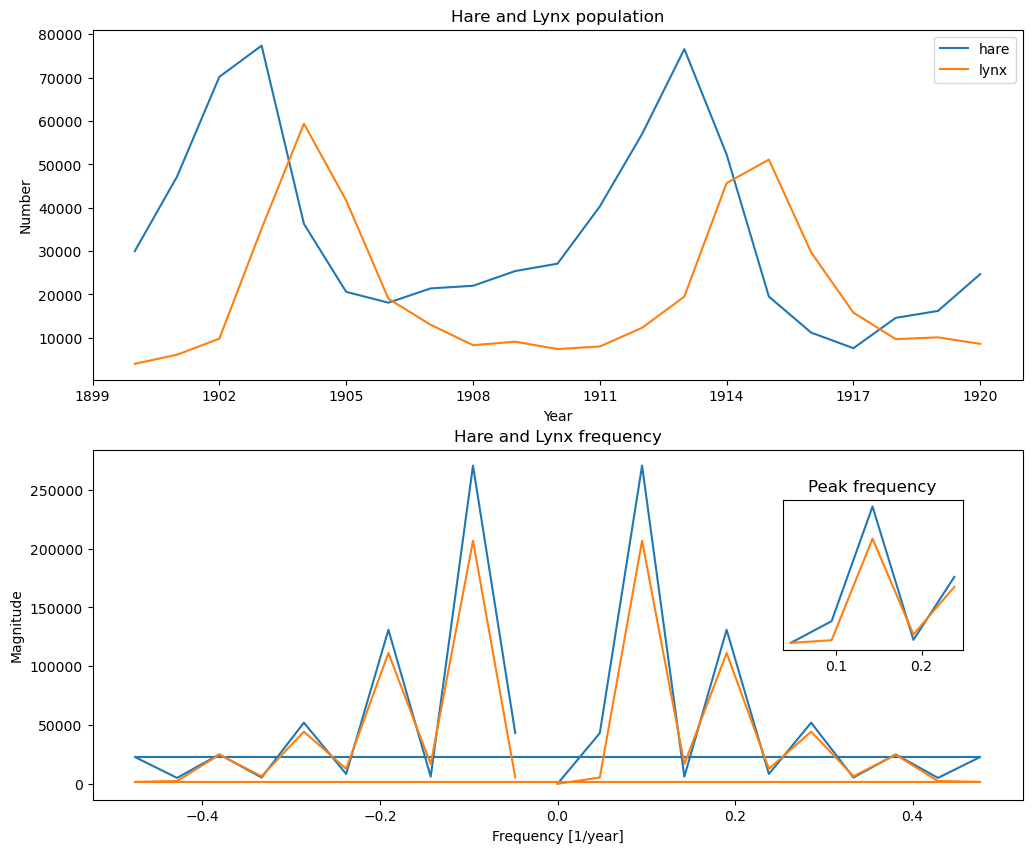

In [4]:
# First we define our variables.
import numpy as np
data = np.loadtxt('populations.txt')
year = data[:,0]
hare = data[:,1]
lynx = data[:,2]

# Now we plot our data to check its periodic form.
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(nrows = 2, ncols = 1, figsize=(12, 10))

ax1.plot(year,hare, label='hare')
ax1.plot(year,lynx,label='lynx')

ax1.set_title('Hare and Lynx population')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number')
ax1.set_xticks(np.arange(1899, 1923, 3))

ax1.legend(loc='best')

# Now we do the FT to performe a periodicity analysis on the lynxs-hares population.
from scipy import fftpack

hare_d = hare - hare.mean() # Because oscilations are around the mean population.
lynx_d = lynx - lynx.mean()

hare_fft = fftpack.fft(hare_d)
lynx_fft = fftpack.fft(lynx_d)
 
hare_mag = np.abs(hare_fft)
lynx_mag = np.abs(lynx_fft)

hare_sample_freq = fftpack.fftfreq(hare.size, d=1) # " d " is the step (1 year).
lynx_sample_freq = fftpack.fftfreq(lynx.size, d=1)

ax2.plot(hare_sample_freq, hare_mag)
ax2.plot(lynx_sample_freq, lynx_mag)

ax2.set_title('Hare and Lynx frequency')
ax2.set_xlabel('Frequency [1/year]')
ax2.set_ylabel('Magnitude')

# We take now only physical frequencies (positive).
pos_mask1 = np.where(hare_sample_freq > 0) 
pos_mask2 = np.where(lynx_sample_freq > 0) 
hare_freqs = hare_sample_freq[pos_mask1]
lynx_freqs = lynx_sample_freq[pos_mask2]

hare_peak_freq = hare_freqs[hare_mag[pos_mask1].argmax()]
lynx_peak_freq = lynx_freqs[lynx_mag[pos_mask2].argmax()]

# Inner plot to show the peak frequency (not necessary).
axes = plt.axes([0.7, 0.26, 0.15, 0.15]) # [left, bottom, width, height].
plt.title('Peak frequency')
plt.plot(hare_freqs[:5], hare_mag[:5])
plt.plot(lynx_freqs[:5], lynx_mag[:5])
plt.setp(axes, yticks=[])

# Dominant periods.
hare_period = 1 / hare_peak_freq
lynx_period = 1 / lynx_peak_freq

print(f'Dominant hare period: {hare_period:.1f} years')
print(f'Dominant lynx period: {lynx_period:.1f} years')
print('As expected, periods are the same')

5\. **FFT of an image**

* Examine the provided image `moonlanding.png`, which is heavily contaminated with periodic noise. In this exercise, we aim to clean up the noise using the Fast Fourier Transform.
* Load the image using pylab.imread().
* Find and use the 2-D FFT function in scipy.fftpack, and plot the spectrum (Fourier transform of) the image. Do you have any trouble visualising the spectrum? If so, why?
* The spectrum consists of high and low frequency components. The noise is contained in the high-frequency part of the spectrum, so set some of those components to zero (use array slicing).
* Apply the inverse Fourier transform to see the resulting image.

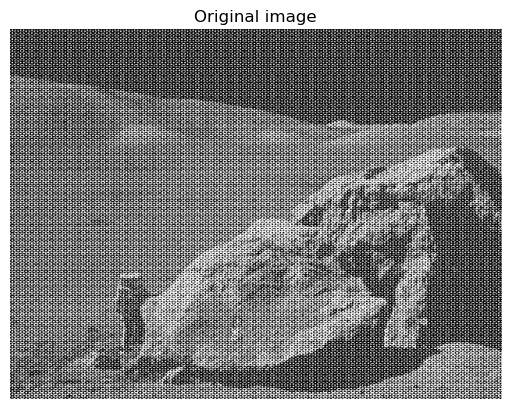

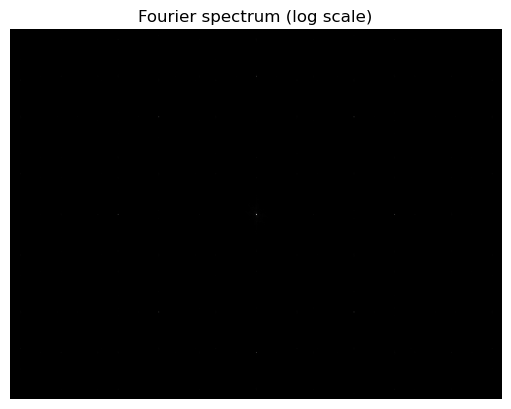

 As we can see, we have to use a logarithmic scale because low frequencies (center of the spectrum) have very large amplitudes.


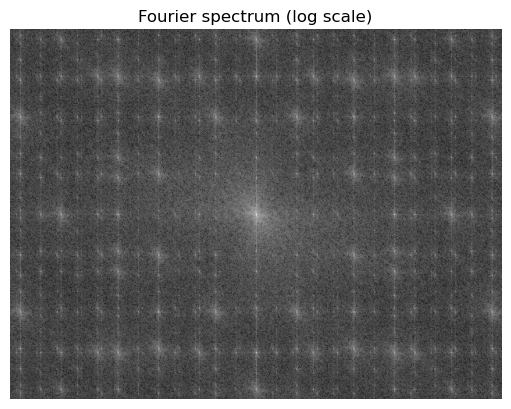

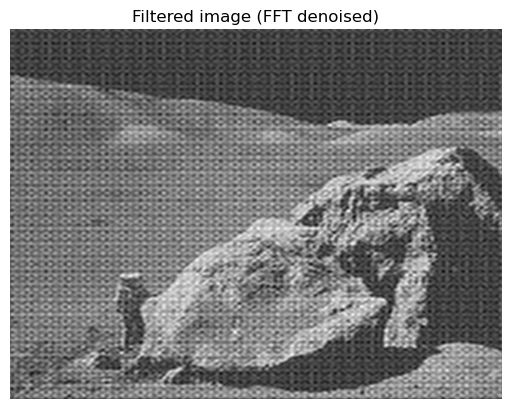

In [5]:
# Load the image using pylab.imread().
from pylab import imread
image = imread('moonlanding.png')

# Spectrum (Fourier transform of) the image.
import matplotlib.pyplot as plt
plt.imshow(image, cmap='gray')
plt.title('Original image')
plt.axis('off')
plt.show()

from scipy import fftpack
Ft = fftpack.fft2(image)
F_shifted = fftpack.fftshift(Ft) # This is to order the data to visualize it.

import numpy as np

magnitude = np.abs(F_shifted)

plt.imshow(magnitude, cmap='gray')
plt.title('Fourier spectrum (log scale)')
plt.axis('off')
plt.show()

print(' As we can see, we have to use a logarithmic scale because low frequencies (center of the spectrum) have very large amplitudes.')
magnitude = np.log(1 + np.abs(F_shifted))

plt.imshow(magnitude, cmap='gray')
plt.title('Fourier spectrum (log scale)')
plt.axis('off')
plt.show()

# The noise is contained in the high-frequency part of the spectrum, so set some of those components to zero (use array slicing).
rows, cols = image.shape
crow, ccol = rows // 2, cols // 2

F_filtered = F_shifted.copy() # Copy of the spectrum so we don't destroy the original.

r = 90 # Size of low-frequency box (tune this!)

mask = np.zeros_like(F_filtered, dtype=bool)
mask[crow-r:crow+r, ccol-r:ccol+r] = True 
F_filtered[~mask] = 0 # ~mask → logical NOT (True ↔ False) so False values are now True and set to 0 (outside ones).
# Central values, that were True, now are false so those aren't set to 0.

F_unshifted = fftpack.ifftshift(F_filtered) # We recover the original number disposition.
image_clean = fftpack.ifft2(F_unshifted) # We do the inverse of the FT.
image_clean = np.real(image_clean)

plt.imshow(image_clean, cmap='gray')
plt.title('Filtered image (FFT denoised)')
plt.axis('off')
plt.show()